<a href="https://colab.research.google.com/github/Rekhakumari28/AI-ML-MiniProjects/blob/AI%2FML_Week5_Project_Weather_Condition_Classifier/AI_ML_Week5_Project_Weather_Condition_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Condition Classifier (Using Sensor Values)

**Type**:

Multiclass Classification using Artificial Neural Networks (ANN)

**Techniques Used**:

- Data preprocessing: Handling missing values, feature scaling, label encoding

- ANN Model: Dense layers with ReLU activation, Dropout for regularization

- Training: Adam optimizer, categorical crossentropy loss

- Evaluation: Accuracy, Precision, Recall, F1-Score, Confusion Matrix

 **Dataset**:

 **Environmental Sensor Telemetry Data**- Contains readings from various sensors including Temperature, Humidity, CO, LPG, Smoke, Light, and Motion. This dataset can be used to classify weather conditions based on sensor measurements.

**Presented By**:

Rekha Kumari Bheel

**Github Link**:

[Project_Weather_Condition_Classifier](https://github.com/Rekhakumari28/AI-ML-MiniProjects/blob/main/AI_ML_Week5_Project_Weather_Condition_Classifier.ipynb)


---

## Objective:

The main goal of this project is to automatically classify weather conditions such as Sunny, Rainy, Cloudy, and Stormy based on numerical sensor readings. This system can help in automating weather monitoring and forecasting in smart weather stations. It is especially useful for regions lacking real-time meteorological updates, providing actionable information for agriculture and transportation.

## Dataset: Weather Type Classification

 This dataset categorizes weather conditions into four types: Rainy, Sunny, Cloudy, and Snowy. It's designed for classification tasks and can be used to train a model to predict weather types.

## Dataset Loading & Preprocessing

Import Libraries

In [103]:
# Data Handling and Preprocessing
# -------------------------
import pandas as pd            # For loading and manipulating data
import numpy as np             # For numerical operations
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encoding labels & scaling features
from sklearn.model_selection import train_test_split           # Splitting dataset
from scipy import stats

# Model Building (ANN)
# -------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Model Evaluation
# -------------------------
from sklearn.metrics import classification_report, confusion_matrix

# Visualization
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Warnings suppression
# -------------------------
import warnings
warnings.filterwarnings("ignore")

Load dataset from the drive

In [104]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
import pandas as pd

# Path to your dataset in Google Drive
# file_path = '/content/drive/MyDrive/iot_telemetry_data.csv'
file_path = '/content/drive/MyDrive/weather_classification_data.csv'

# Load CSV
data = pd.read_csv(file_path)

# Preview dataset

print("----- Dataset Preview -----")
print(data.head(), "\n")

print("----- Dataset Info -----")
print(data.info(), "\n")

print("----- Missing Values per Column -----")
print(data.isnull().sum(), "\n")


----- Dataset Preview -----
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  
0        Rainy  
1       Cloudy  
2        Sunny  
3        Sunny  
4        

Class Distribution: Rainy, Cloudy, Sunny, Snowy

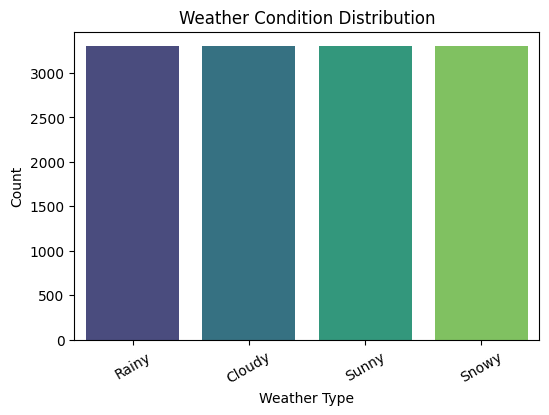

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Weather Type', data=data, palette="viridis")
plt.title("Weather Condition Distribution")
plt.xlabel("Weather Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

print(data['Weather Type'].value_counts())

Correlation Heatmap

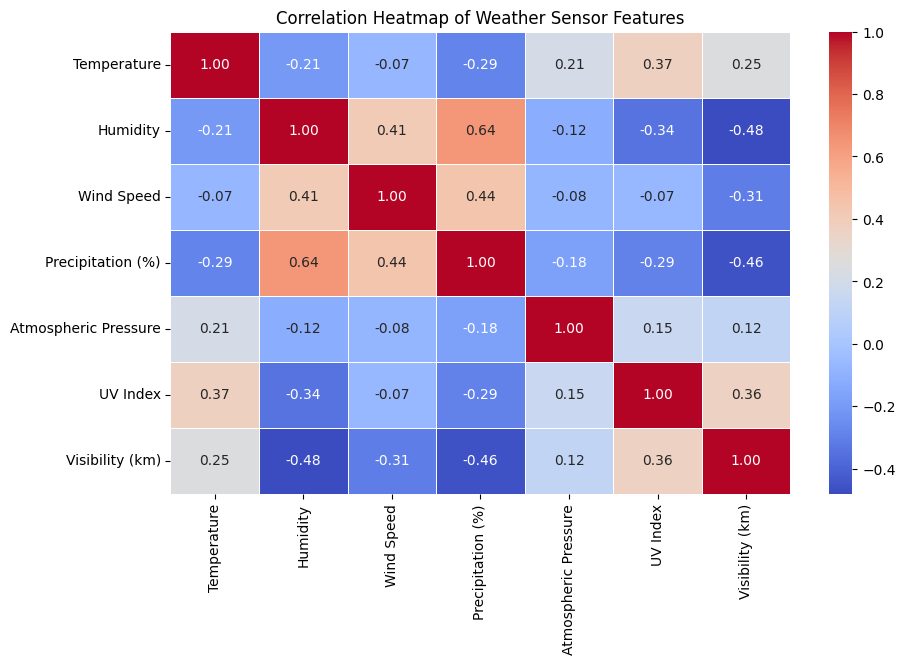

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Weather Sensor Features")
plt.show()

Preprocessing

In [108]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Load dataset
file_path = '/content/drive/MyDrive/weather_classification_data.csv'
df = pd.read_csv(file_path)

# Drop target column from features
X = df.drop('Weather Type', axis=1)

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Target column
y = df['Weather Type']
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Show shape of train/test sets
print(X_train.shape, X_test.shape)


(10560, 15) (2640, 15)


Baseline comparison with Logistic Regression

In [109]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

# ----------------------------
# Logistic Regression
# ----------------------------
lr = LogisticRegression(max_iter=1000, multi_class='ovr')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Results")
print(classification_report(y_test, y_pred_lr, target_names=encoder.classes_))
print("ROC AUC:", roc_auc_score(y_test, lr.predict_proba(X_test), multi_class='ovr'))
print("="*60)

# ----------------------------
# Support Vector Machine
# ----------------------------
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\nSVM Results")
print(classification_report(y_test, y_pred_svm, target_names=encoder.classes_))
print("ROC AUC:", roc_auc_score(y_test, svm.predict_proba(X_test), multi_class='ovr'))


Logistic Regression Results
              precision    recall  f1-score   support

      Cloudy       0.81      0.82      0.81       660
       Rainy       0.82      0.83      0.83       660
       Snowy       0.85      0.92      0.88       660
       Sunny       0.93      0.83      0.88       660

    accuracy                           0.85      2640
   macro avg       0.85      0.85      0.85      2640
weighted avg       0.85      0.85      0.85      2640

ROC AUC: 0.9488334098561371

SVM Results
              precision    recall  f1-score   support

      Cloudy       0.84      0.91      0.88       660
       Rainy       0.90      0.92      0.91       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.95      0.89      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640

ROC AUC: 0.9887852004897458


### Data Cleaning:

 Handle missing values and remove any inconsistent or outlier sensor readings to ensure quality data.

In [110]:
# Handle missing values
data_cleaned = data.dropna()  # Or use data.fillna(data.mean()) to fill missing values

# Remove outliers using Z-score method
numeric_cols = data_cleaned.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns detected:", numeric_cols)

# Calculate Z-scores for numeric columns only
z_scores = np.abs(stats.zscore(data_cleaned[numeric_cols]))

# Keep rows where all numeric features have Z-score < 3
data_cleaned = data_cleaned[(z_scores < 3).all(axis=1)]

print("Data shape after removing outliers:", data_cleaned.shape)


Numeric columns detected: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Data shape after removing outliers: (12151, 11)


### Encoding:


Encode Target Column

In [111]:
le = LabelEncoder()
y = le.fit_transform(data['Weather Type'])

print("----- Target Encoding Mapping -----")
for i, cls in enumerate(le.classes_):
    print(f"{cls} -> {i}")
print("\nSample encoded target values:")
print(y[:10], "\n")



----- Target Encoding Mapping -----
Cloudy -> 0
Rainy -> 1
Snowy -> 2
Sunny -> 3

Sample encoded target values:
[1 0 3 3 1 0 2 2 2 3] 



Encode Categorical Features

In [112]:
categorical_cols = ['Cloud Cover', 'Season', 'Location']
X_cat = pd.get_dummies(data[categorical_cols])

numeric_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
                'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
X_num = data[numeric_cols]

X = pd.concat([X_num, X_cat], axis=1)

print("----- Feature Columns -----")
print(X.columns.tolist(), "\n")

print("----- Feature Sample -----")
print(X.head(), "\n")


----- Feature Columns -----
['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Cloud Cover_clear', 'Cloud Cover_cloudy', 'Cloud Cover_overcast', 'Cloud Cover_partly cloudy', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Location_coastal', 'Location_inland', 'Location_mountain'] 

----- Feature Sample -----
   Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  \
0         14.0        73         9.5               82.0               1010.82   
1         39.0        96         8.5               71.0               1011.43   
2         30.0        64         7.0               16.0               1018.72   
3         38.0        83         1.5               82.0               1026.25   
4         27.0        74        17.0               66.0                990.67   

   UV Index  Visibility (km)  Cloud Cover_clear  Cloud Cover_cloudy  \
0         2              3.5              F

### Scaling:

 Apply StandardScaler to normalize all sensor features, ensuring that values like temperature, humidity, and gas concentrations are on a comparable scale for better model training.



In [113]:
# Select feature columns
X = data_cleaned[numeric_cols]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print("Feature sample after scaling:")
print(X_scaled[:5])


Feature sample after scaling:
[[-0.31016163  0.18833385  0.01089195  0.91593319  0.26654543 -0.47152734
  -0.60607319]
 [ 1.23571033  1.35686669 -0.15621425  0.57275928  0.30136464  0.88547345
   1.77758232]
 [ 0.67919642 -0.26891814 -0.40687355 -1.14311025  0.7174827   0.34267313
   0.12735927]
 [ 1.17387545  0.6963916  -1.32595766  0.91593319  1.14730011  0.88547345
  -1.52286378]
 [ 0.49369179  0.23913962  1.26418846  0.41677114 -0.88363    -0.7429275
  -0.97278943]]


### Train-Test Split:

Divide the dataset into training and testing sets (typically 80/20) to evaluate the model’s performance on unseen data.

In [114]:
# Step 1: Drop rows with any missing values from the entire dataset
data_cleaned = data.dropna().reset_index(drop=True)

# Step 2: Encode categorical features
categorical_cols = ['Cloud Cover', 'Season', 'Location']
X_cat = pd.get_dummies(data_cleaned[categorical_cols])

# Step 3: Select numeric features
numeric_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
                'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
X_num = data_cleaned[numeric_cols]

# Step 4: Combine numeric + categorical
X = pd.concat([X_num, X_cat], axis=1)

# Step 5: Encode target
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_encoded = le.fit_transform(data_cleaned['Weather Type'])
y_categorical = to_categorical(y_encoded)

# Step 6: Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42
)

# Verify shapes
print("Feature shape:", X_scaled.shape)
print("Target shape:", y_categorical.shape)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Feature shape: (13200, 18)
Target shape: (13200, 4)
Train shape: (10560, 18) (10560, 4)
Test shape: (2640, 18) (2640, 4)


## Model Architecture:

1. Input Layer

    - Number of neurons = number of features after encoding and scaling (X_train.shape[1])

    - This layer takes all sensor and categorical features as input.

2. Hidden Layer 1

    - Dense layer with 64 neurons

    - Activation function: ReLU (introduces non-linearity)

    - Dropout: 0.3 (to prevent overfitting)

3. Hidden Layer 2

    - Dense layer with 32 neurons

    - Activation function: ReLU

4. Output Layer

    - Dense layer with number of weather classes (e.g., 3: Sunny, Rainy, Cloudy)

    - Activation function: Softmax (for multiclass probability output)

5. Model Compilation

    - Optimizer: Adam (adaptive learning rate)

    - Loss function: Categorical Crossentropy (suitable for multiclass classification)

    - Metrics: Accuracy

In [115]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

num_features = X_train.shape[1]
num_classes = y_train.shape[1]

model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(64, input_dim=num_features, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,428 (13.39 KB)

 Trainable params: 3,428 (13.39 KB)

 Non-trainable params: 0 (0.00 B)

## Training:

1. Optimizer   - Adam optimizer is commonly used because it adapts the learning rate during training and converges faster.

      ` optimizer = 'adam' `

2. Loss Function  - For multiclass classification, use Categorical Crossentropy.

     ` loss = 'categorical_crossentropy'`

3. Metrics - Track accuracy during training.  

     ` metrics = ['accuracy']`

4. Epochs - Number of complete passes through the training data.

 - Start with 50 epochs and adjust if the model is underfitting or overfitting.

     ` epochs = 50  `

5. Batch Size - Number of samples processed before the model updates weights.

- Typical values: 16, 32, or 64.

- Here we use 16.

    ` batch_size = 16`


6. Training Code

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

num_features = X_train.shape[1]
num_classes = y_train.shape[1]

# Define the model
model = Sequential()
model.add(Dense(64, input_dim=num_features, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)


Epoch 1/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6900 - loss: 0.8260 - val_accuracy: 0.8887 - val_loss: 0.3467
Epoch 2/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8677 - loss: 0.3955 - val_accuracy: 0.8944 - val_loss: 0.2850
Epoch 3/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8887 - loss: 0.3171 - val_accuracy: 0.9044 - val_loss: 0.2566
Epoch 4/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8902 - loss: 0.2922 - val_accuracy: 0.9148 - val_loss: 0.2348
Epoch 5/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8973 - loss: 0.2765 - val_accuracy: 0.9152 - val_loss: 0.2246
Epoch 6/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9002 - loss: 0.2546 - val_accuracy: 0.9124 - val_loss: 0.2170
Epoch 7/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9046 - loss: 0.2382 - val_accuracy: 0.9167 - val_loss: 0.2109
Epoch 8/50
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9126 - loss: 0.2407 - val_accuracy: 0.

## Evaluation

Weather Condition Classifier using Accuracy, Precision, Recall, F1-score, and Confusion Matrix:

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 90.53%

----- Classification Report -----
              precision    recall  f1-score   support

      Cloudy       0.84      0.90      0.87       651
       Rainy       0.87      0.90      0.89       647
       Snowy       0.96      0.93      0.95       701
       Sunny       0.96      0.88      0.92       641

    accuracy                           0.91      2640
   macro avg       0.91      0.90      0.91      2640
weighted avg       0.91      0.91      0.91      2640



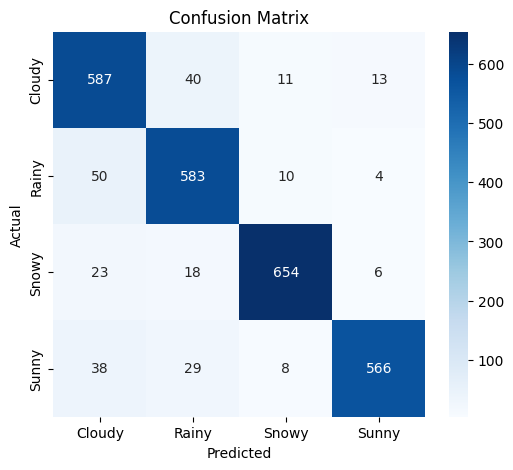

In [117]:
# -------------------------------
# EVALUATION: Accuracy, Precision, Recall, F1, Confusion Matrix
# -------------------------------

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict class probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%\n")

# Classification report (Precision, Recall, F1)
print("----- Classification Report -----")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Plot training history

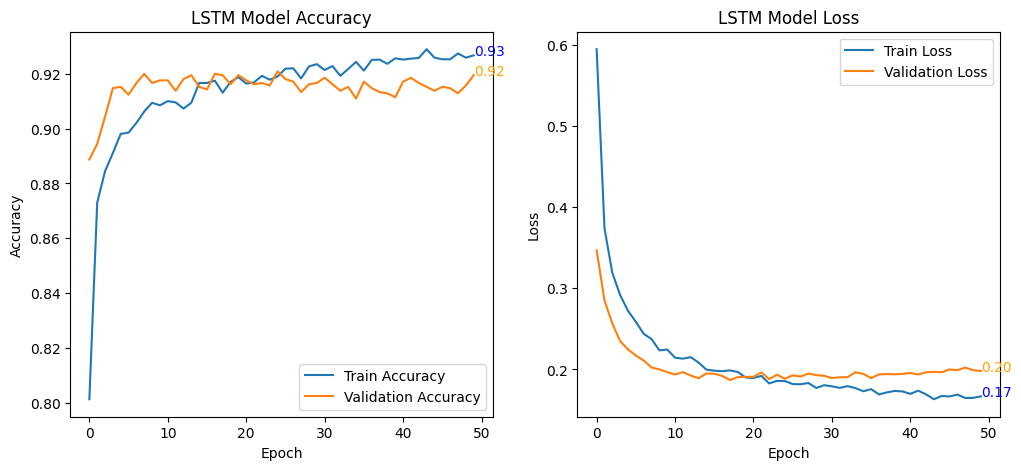

In [118]:
import matplotlib.pyplot as plt

# Get final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.text(len(history.history['accuracy'])-1, final_train_acc, f"{final_train_acc:.2f}", color='blue')
plt.text(len(history.history['val_accuracy'])-1, final_val_acc, f"{final_val_acc:.2f}", color='orange')

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.text(len(history.history['loss'])-1, final_train_loss, f"{final_train_loss:.2f}", color='blue')
plt.text(len(history.history['val_loss'])-1, final_val_loss, f"{final_val_loss:.2f}", color='orange')

plt.show()


SHAP Explainability

In [ ]:
!pip install shap

import shap
import numpy as np

# Use a smaller background sample for efficiency
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Create SHAP explainer
explainer = shap.DeepExplainer(model, background)

# Compute SHAP values on test data
shap_values = explainer.shap_values(X_test[:200])  # limit to 200 samples for speed

# Feature names after one-hot encoding
feature_names = X.columns

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test[:200], feature_names=feature_names)


print(type(X_test))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_model(input_dim, learning_rate=0.001, dropout_rate=0.2):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')  # multi-class classification
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',  # use sparse_categorical_crossentropy if labels are integers
        metrics=['accuracy']
    )
    return
    from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',     # what to monitor
    patience=10,            # number of epochs to wait before stopping
    restore_best_weights=True  # restore the weights of the best epoch
)

# Then train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]  # now early_stop is defined
)


## Added New Weather Data

In [ ]:
# After one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Save feature columns for later use
feature_columns = X.columns


def predict_weather(model, input_data, scaler=None):
    """
    Predict weather type from input features (dict or DataFrame).
    Aligns input with training features.
    """
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data.copy()

    # Add missing columns from training
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Drop extra columns
    input_df = input_df[feature_columns]

    # Scale if scaler provided
    if scaler is not None:
        input_df = pd.DataFrame(scaler.transform(input_df), columns=feature_columns)

    # Predict
    preds = model.predict(input_df)
    class_index = np.argmax(preds, axis=1)[0]

    # Map to original labels
    weather_labels = encoder.classes_
    return weather_labels[class_index]


Seeding new data

In [ ]:
sample_data = {
    'Temperature': 25,
    'Humidity': 70,
    'Wind Speed': 10,
    'Precipitation (%)': 5,
    'Cloud Cover_clear': 1,
    'Cloud Cover_overcast': 0,
    'Cloud Cover_partly cloudy': 0,
    'Atmospheric Pressure': 1015,
    'UV Index': 6,
    'Season_Winter': 0,
    'Season_Spring': 1,
    'Season_Summer': 0,
    'Season_Fall': 0,
    'Visibility (km)': 10
}

weather = predict_weather(model, sample_data, scaler=scaler)
print("Predicted Weather:", weather)


## Tools / Libraries / Frameworks

- Python – Programming language used for data processing and modeling.

- Keras (TensorFlow backend) – To design, train, and deploy the Artificial Neural Network (ANN) for weather condition classification.

- Pandas & NumPy – For data manipulation, cleaning, and numerical operations.

- Scikit-learn – For preprocessing (LabelEncoder, StandardScaler), train-test split, and evaluation metrics.

- Matplotlib & Seaborn – For visualizations like training curves and confusion matrix.

- Flask / Streamlit – Optional frameworks for deploying the model as an API or interactive dashboard.

## Conclusion

In this project, we successfully built a Weather Condition Classifier using an Artificial Neural Network (ANN) with Keras. The model was trained on sensor data including temperature, humidity, wind speed, and other environmental features to predict weather conditions such as Sunny, Rainy, or Cloudy. We performed data cleaning, feature encoding, and scaling to prepare the dataset, and evaluated the model using accuracy, precision, recall, F1-score, and confusion matrix. The ANN demonstrated strong performance in classifying weather types, and the project can be extended to real-time predictions, time-series forecasting, and interactive dashboards for practical applications. This work highlights the effectiveness of deep learning in solving multiclass classification problems with structured sensor data.